In [24]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [25]:
data = pd.read_csv("skin cancer classification.csv")

print(data.head())
print(data.shape)

                             image_path  label  split
0  HAM10000_all_images/ISIC_0029913.jpg      6      0
1  HAM10000_all_images/ISIC_0029206.jpg      2      0
2  HAM10000_all_images/ISIC_0029154.jpg      4      0
3  HAM10000_all_images/ISIC_0029429.jpg      4      0
4  HAM10000_all_images/ISIC_0029372.jpg      1      0
(700, 3)


In [26]:
data = pd.read_csv("skin cancer classification.csv")

data["image_path"] = data["image_path"].str.replace(
    "HAM10000_all_images", "HAM10000_images"
)

In [27]:
data["label"] = data["label"].astype(str)

In [28]:
train_df = data[data["split"] == 0]
test_df = data[data["split"] == 1]

print("Train images:", len(train_df))
print("Test images:", len(test_df))

Train images: 490
Test images: 70


In [29]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [30]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 490 validated image filenames belonging to 7 classes.
Found 70 validated image filenames belonging to 7 classes.


In [31]:
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(7,activation='softmax')

])

c:\Users\Hp\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.1816 - loss: 2.3565 - val_accuracy: 0.1714 - val_loss: 1.9706
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.2347 - loss: 1.8257 - val_accuracy: 0.2000 - val_loss: 1.9317
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.2694 - loss: 1.7711 - val_accuracy: 0.2714 - val_loss: 1.8547
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.3163 - loss: 1.7004 - val_accuracy: 0.2571 - val_loss: 1.8971
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.4082 - loss: 1.5546 - val_accuracy: 0.3000 - val_loss: 1.7913
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.4020 - loss: 1.4952 - val_accuracy: 0.3714 - val_loss: 1.5517
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.4184 - loss: 1.5070 - val_accuracy: 0.4571 - val_loss: 1.5002
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.4327 - loss: 1.3943 - val_accuracy: 0.4571 - val_loss:

In [34]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.3857 - loss: 1.4465
Test Accuracy: 0.3857142925262451


In [35]:
model.save("skin_cancer_model.h5")

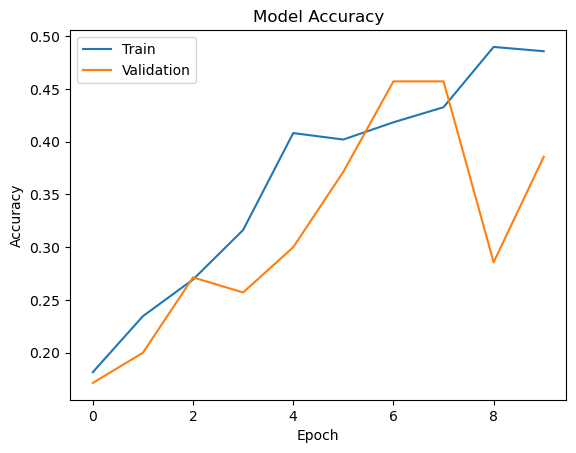

In [36]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train','Validation'])

plt.show()

In [37]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "HAM10000_images/ISIC_0029913.jpg",
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Predicted Class:", prediction.argmax())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
Predicted Class: 2
